In [1]:
import pandas as pd

from fetch_datasets import fetch_datasets
from preprocess_datasets import preprocess
from data_splitting import data_splitting
from model import solar_predictor_model
from train import train_my_model
from test import test_model
from evaluate import evaluate_model

from dataset import SolarDataset
from torch.utils.data import DataLoader


import matplotlib.pyplot as plt



#first step is to fetch the datasets and save them
fetch_datasets()

data_chester = pd.read_csv(f'./data_chester.csv')
data_chester.head(10)


/Users/benji/Documents/dissertation/python_environment/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


CSV created successfully with shape: (26280, 12)
CSV created successfully with shape: (26280, 12)


,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M
0,2023,1,1,0,0.00,0.0,13.22,90.00,99.38,86.68,11.24,3.57
1,2023,1,1,1,0.00,0.0,0.03,90.00,99.36,88.75,10.80,3.57
2,2023,1,1,2,0.00,0.0,2.10,90.00,99.35,91.08,10.39,3.58
3,2023,1,1,3,0.00,0.0,4.17,90.00,99.36,92.55,10.11,3.59
4,2023,1,1,4,0.00,0.0,18.84,90.00,99.37,92.74,10.06,3.79
5,2023,1,1,5,0.00,0.0,22.30,90.00,99.40,91.85,10.27,4.09
6,2023,1,1,6,0.00,0.0,76.45,90.00,99.45,90.95,10.61,4.37
7,2023,1,1,7,12.57,9.8,79.83,88.45,99.50,90.48,11.00,4.58
8,2023,1,1,8,153.30,113.8,82.11,79.03,99.53,88.09,12.08,4.89
9,2023,1,1,9,326.42,243.8,85.31,69.62,99.56,85.59,13.54,4.73


In [2]:
data_lagos = pd.read_csv(f'./data_lagos.csv')
data_lagos.head(10)

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M
0,2023,1,1,0,0.00,0.00,0.31,90.00,92.65,84.71,18.57,0.71
1,2023,1,1,1,0.00,0.00,6.56,90.00,92.58,85.04,18.01,0.70
2,2023,1,1,2,0.00,0.00,0.62,90.00,92.52,85.36,17.47,0.71
3,2023,1,1,3,0.00,0.00,1.23,90.00,92.49,85.49,17.00,0.70
4,2023,1,1,4,0.00,0.00,0.93,90.00,92.49,86.27,16.46,0.65
5,2023,1,1,5,0.00,0.00,2.78,90.00,92.50,86.01,16.12,0.59
6,2023,1,1,6,9.98,9.88,2.28,88.37,92.53,85.81,16.03,0.57
7,2023,1,1,7,167.43,165.93,1.79,76.58,92.61,81.26,18.74,0.45
8,2023,1,1,8,385.42,383.55,1.30,63.33,92.68,66.21,21.64,0.64
9,2023,1,1,9,604.38,603.33,0.80,50.77,92.68,54.08,24.92,0.63


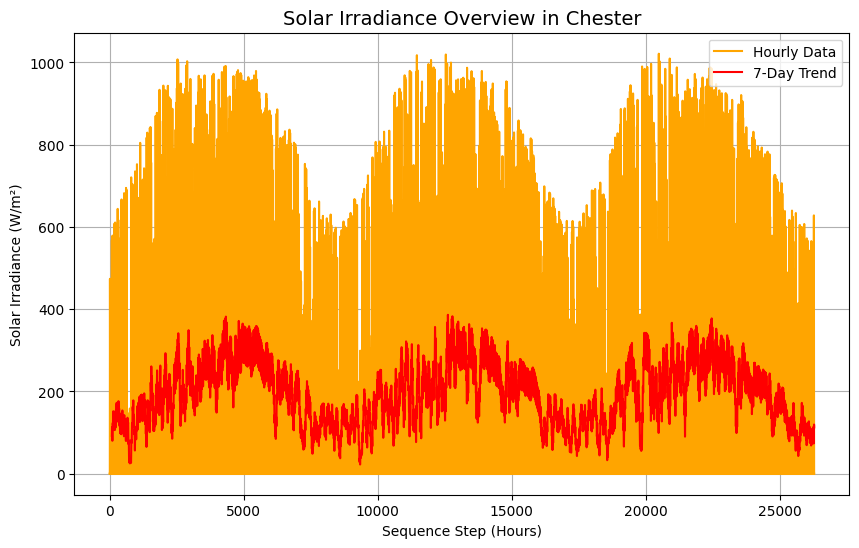

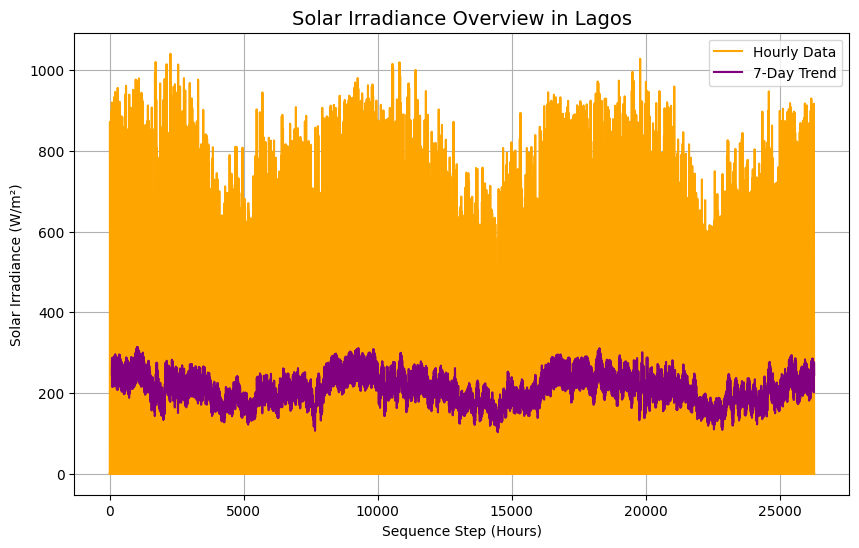

In [3]:
target_col = 'ALLSKY_SFC_SW_DWN' # This is the column we want to visualize

plt.figure(figsize=(10, 6))
plt.plot(data_chester[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(data_chester[target_col].rolling(window=84).mean(), color='red', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(data_lagos[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(data_lagos[target_col].rolling(window=84).mean(), color='purple', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()

In [4]:

#second step is to preprocess the datasets and save them
preprocess(data_chester, data_lagos)

preprocessed_data_chester = pd.read_csv(f'./preprocessed_chester.csv')
preprocessed_data_lagos = pd.read_csv(f'./preprocessed_lagos.csv')


In [95]:
preprocessed_data_chester.head(10)

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M,Hour_sine,Hour_cosine,DayOfYear,DayOfYear_sine,DayOfYear_cosine
0,2023,1,1,0,0.000000,0.000000,0.1322,1.000000,0.413306,0.848997,0.399536,0.363169,0.000000,1.000000e+00,1,0.017202,0.999852
1,2023,1,1,1,0.000000,0.000000,0.0003,1.000000,0.409274,0.872463,0.391685,0.363169,0.258819,9.659258e-01,1,0.017202,0.999852
2,2023,1,1,2,0.000000,0.000000,0.0210,1.000000,0.407258,0.898878,0.384368,0.364198,0.500000,8.660254e-01,1,0.017202,0.999852
3,2023,1,1,3,0.000000,0.000000,0.0417,1.000000,0.409274,0.915542,0.379372,0.365226,0.707107,7.071068e-01,1,0.017202,0.999852
4,2023,1,1,4,0.000000,0.000000,0.1884,1.000000,0.411290,0.917696,0.378480,0.385802,0.866025,5.000000e-01,1,0.017202,0.999852
5,2023,1,1,5,0.000000,0.000000,0.2230,1.000000,0.417339,0.907607,0.382227,0.416667,0.965926,2.588190e-01,1,0.017202,0.999852
6,2023,1,1,6,0.000000,0.000000,0.7645,1.000000,0.427419,0.897404,0.388294,0.445473,1.000000,6.123234e-17,1,0.017202,0.999852
7,2023,1,1,7,0.012255,0.009597,0.7983,0.980642,0.437500,0.892076,0.395253,0.467078,0.965926,-2.588190e-01,1,0.017202,0.999852
8,2023,1,1,8,0.149462,0.111446,0.8211,0.862995,0.443548,0.864981,0.414525,0.498971,0.866025,-5.000000e-01,1,0.017202,0.999852
9,2023,1,1,9,0.318247,0.238757,0.8531,0.745473,0.449597,0.836640,0.440578,0.482510,0.707107,-7.071068e-01,1,0.017202,0.999852


In [96]:
preprocessed_data_lagos.head(10)

,YEAR,MO,DY,HR,CLRSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DWN,CLOUD_AMT,SZA,PS,RH2M,T2M,WS2M,Hour_sine,Hour_cosine,DayOfYear,DayOfYear_sine,DayOfYear_cosine
0,2023,1,1,0,0.000000,0.000000,0.0031,1.000000,0.642276,0.810767,0.227230,0.384615,0.000000,1.000000e+00,1,0.017202,0.999852
1,2023,1,1,1,0.000000,0.000000,0.0656,1.000000,0.585366,0.814851,0.200664,0.379121,0.258819,9.659258e-01,1,0.017202,0.999852
2,2023,1,1,2,0.000000,0.000000,0.0062,1.000000,0.536585,0.818812,0.175047,0.384615,0.500000,8.660254e-01,1,0.017202,0.999852
3,2023,1,1,3,0.000000,0.000000,0.0123,1.000000,0.512195,0.820421,0.152751,0.379121,0.707107,7.071068e-01,1,0.017202,0.999852
4,2023,1,1,4,0.000000,0.000000,0.0093,1.000000,0.512195,0.830074,0.127135,0.351648,0.866025,5.000000e-01,1,0.017202,0.999852
5,2023,1,1,5,0.000000,0.000000,0.0278,1.000000,0.520325,0.826856,0.111006,0.318681,0.965926,2.588190e-01,1,0.017202,0.999852
6,2023,1,1,6,0.009525,0.009492,0.0228,0.980864,0.544715,0.824381,0.106736,0.307692,1.000000,6.123234e-17,1,0.017202,0.999852
7,2023,1,1,7,0.159792,0.159410,0.0179,0.842451,0.609756,0.768069,0.235294,0.241758,0.965926,-2.588190e-01,1,0.017202,0.999852
8,2023,1,1,8,0.367837,0.368479,0.0130,0.686898,0.666667,0.581807,0.372865,0.346154,0.866025,-5.000000e-01,1,0.017202,0.999852
9,2023,1,1,9,0.576809,0.579623,0.0080,0.539446,0.666667,0.431683,0.528463,0.340659,0.707107,-7.071068e-01,1,0.017202,0.999852


Target column starts at index: 26256


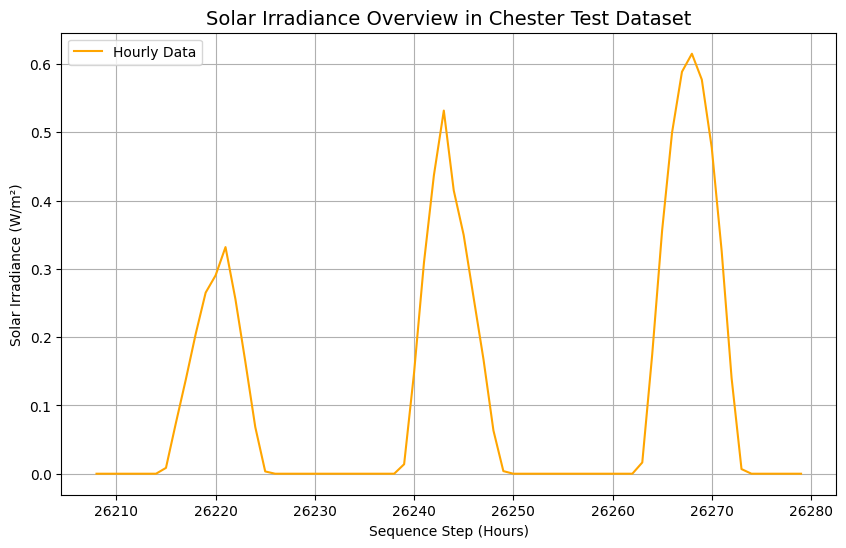

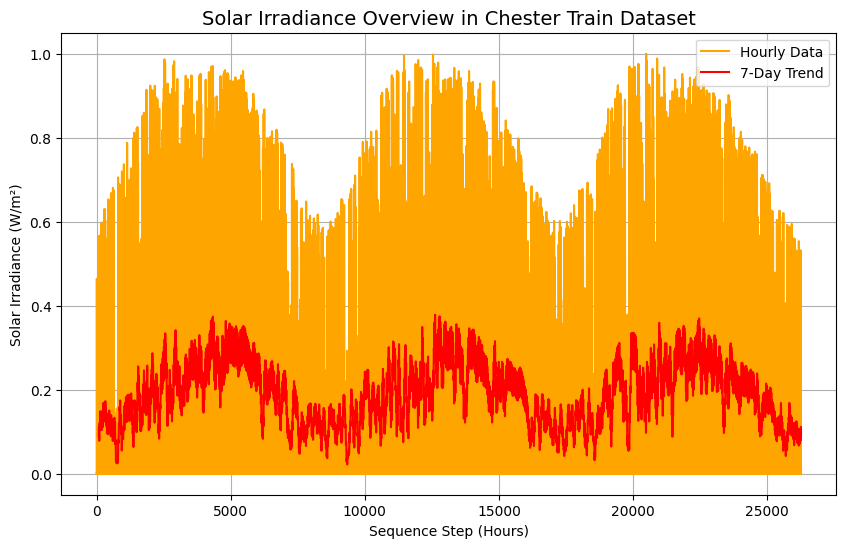

,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
0,0.000000,0.000000,0.1322,1.000000,0.399536,0.848997,0.413306,0.363169,0.000000,1.000000e+00,0.017202,0.999852
1,0.000000,0.000000,0.0003,1.000000,0.391685,0.872463,0.409274,0.363169,0.258819,9.659258e-01,0.017202,0.999852
2,0.000000,0.000000,0.0210,1.000000,0.384368,0.898878,0.407258,0.364198,0.500000,8.660254e-01,0.017202,0.999852
3,0.000000,0.000000,0.0417,1.000000,0.379372,0.915542,0.409274,0.365226,0.707107,7.071068e-01,0.017202,0.999852
4,0.000000,0.000000,0.1884,1.000000,0.378480,0.917696,0.411290,0.385802,0.866025,5.000000e-01,0.017202,0.999852
5,0.000000,0.000000,0.2230,1.000000,0.382227,0.907607,0.417339,0.416667,0.965926,2.588190e-01,0.017202,0.999852
6,0.000000,0.000000,0.7645,1.000000,0.388294,0.897404,0.427419,0.445473,1.000000,6.123234e-17,0.017202,0.999852
7,0.009597,0.012255,0.7983,0.980642,0.395253,0.892076,0.437500,0.467078,0.965926,-2.588190e-01,0.017202,0.999852
8,0.111446,0.149462,0.8211,0.862995,0.414525,0.864981,0.443548,0.498971,0.866025,-5.000000e-01,0.017202,0.999852
9,0.238757,0.318247,0.8531,0.745473,0.440578,0.836640,0.449597,0.482510,0.707107,-7.071068e-01,0.017202,0.999852


In [5]:
# Split the preprocessed data into training and testing sets

chester_train, chester_test, lagos_train, lagos_test, id = data_splitting(preprocessed_data_chester, preprocessed_data_lagos)
print(f"Target column starts at index: {id}")
plt.figure(figsize=(10, 6))
plt.plot(chester_test[target_col], color='orange', label='Hourly Data')
plt.title('Solar Irradiance Overview in Chester Test Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(chester_train[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(chester_train[target_col].rolling(window=84).mean(), color='red', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Chester Train Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()
chester_train.head(10)

Target column starts at index: 26256


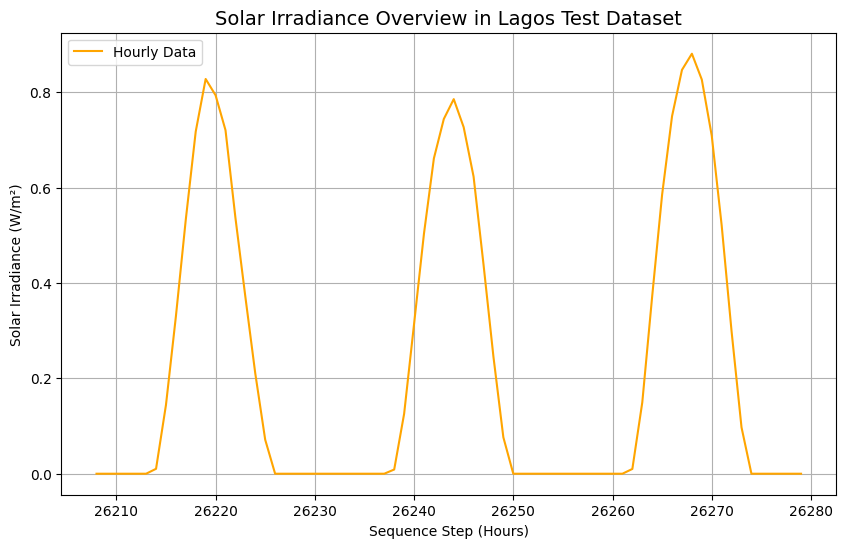

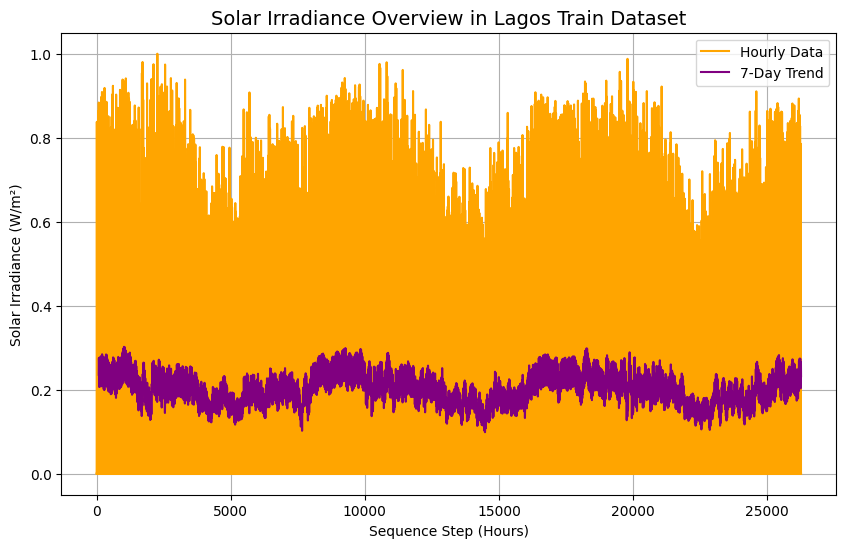

,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,CLOUD_AMT,SZA,T2M,RH2M,PS,WS2M,Hour_sine,Hour_cosine,DayOfYear_sine,DayOfYear_cosine
0,0.000000,0.000000,0.0031,1.000000,0.227230,0.810767,0.642276,0.384615,0.000000,1.000000e+00,0.017202,0.999852
1,0.000000,0.000000,0.0656,1.000000,0.200664,0.814851,0.585366,0.379121,0.258819,9.659258e-01,0.017202,0.999852
2,0.000000,0.000000,0.0062,1.000000,0.175047,0.818812,0.536585,0.384615,0.500000,8.660254e-01,0.017202,0.999852
3,0.000000,0.000000,0.0123,1.000000,0.152751,0.820421,0.512195,0.379121,0.707107,7.071068e-01,0.017202,0.999852
4,0.000000,0.000000,0.0093,1.000000,0.127135,0.830074,0.512195,0.351648,0.866025,5.000000e-01,0.017202,0.999852
5,0.000000,0.000000,0.0278,1.000000,0.111006,0.826856,0.520325,0.318681,0.965926,2.588190e-01,0.017202,0.999852
6,0.009492,0.009525,0.0228,0.980864,0.106736,0.824381,0.544715,0.307692,1.000000,6.123234e-17,0.017202,0.999852
7,0.159410,0.159792,0.0179,0.842451,0.235294,0.768069,0.609756,0.241758,0.965926,-2.588190e-01,0.017202,0.999852
8,0.368479,0.367837,0.0130,0.686898,0.372865,0.581807,0.666667,0.346154,0.866025,-5.000000e-01,0.017202,0.999852
9,0.579623,0.576809,0.0080,0.539446,0.528463,0.431683,0.666667,0.340659,0.707107,-7.071068e-01,0.017202,0.999852


In [6]:
print(f"Target column starts at index: {id}")
plt.figure(figsize=(10, 6))
plt.plot(lagos_test[target_col], color='orange', label='Hourly Data')
plt.title('Solar Irradiance Overview in Lagos Test Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.figure(figsize=(10, 6))
plt.plot(lagos_train[target_col], color='orange', label='Hourly Data')
# # Adding a rolling mean to see the seasonal trend (e.g., 7-day window)
# If your day is ~12 steps after cleaning, 7 days = 84 steps
plt.plot(lagos_train[target_col].rolling(window=84).mean(), color='purple', label='7-Day Trend')
plt.title('Solar Irradiance Overview in Lagos Train Dataset', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.grid(True, alpha=1)

plt.show()
lagos_train.head(10)

In [7]:
# Create the Dataset objects for both cities
# This uses the data frames returned by your data_splitting function
chester_ds = SolarDataset(chester_train, window=48, forecast=24)

# Create the DataLoaders
# batch_size=32: We process 32 different 'days' at the same time to speed up math
# shuffle=True: We mix up the days so the model doesn't just memorize the calendar
# drop_last=True: If the last batch is smaller than 32, we ignore it to keep math consistent
chester_loader = DataLoader(chester_ds, batch_size=32, shuffle=True, drop_last=True)

In [8]:
train_x, train_y = next(iter(chester_loader))

# This shows the 3D shape: [Number of Windows, Number of Hours, Number of Features]
print(f"Input Shape: {train_x.shape}")

# This shows the 2D Target: [Number of Windows, Number of Hours to Predict]
print(f"Target Shape: {train_y.shape}") 


Input Shape: torch.Size([32, 48, 12])
Target Shape: torch.Size([32, 24])


In [ ]:
# 1. Train LSTM for Chester

lstm_chester = solar_predictor_model(12, 64, model_type='LSTM')

train_my_model(lstm_chester, chester_loader, epochs=100)

Starting Training for LSTM...
Epoch [10/100],  Loss: 0.006647
Epoch [20/100],  Loss: 0.004451
Epoch [30/100],  Loss: 0.002099
Epoch [40/100],  Loss: 0.001340
Epoch [50/100],  Loss: 0.000993
Epoch [60/100],  Loss: 0.000849
Epoch [70/100],  Loss: 0.000667
Epoch [80/100],  Loss: 0.000621
Epoch [90/100],  Loss: 0.000537
Epoch [100/100],  Loss: 0.000544
Training Complete!


In [10]:

print(len(chester_test))  # Check the column length to confirm
chester_ds_test = SolarDataset(chester_test, window=48, forecast=24)
# 3. Create the loader
chester_test_loader = DataLoader(chester_ds_test, batch_size=32, shuffle=False)

# Get predictions for LSTM
chester_lstm_preds, chester_actuals = test_model(lstm_chester, chester_test_loader)



72


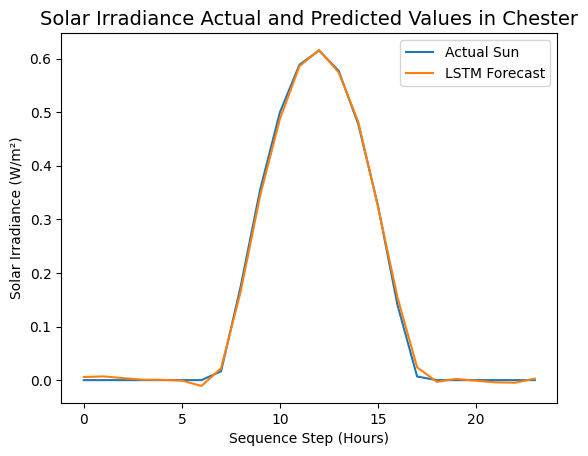

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.         0.0164819  0.17454363 0.35635382 0.49952993 0.5886478
 0.6150893  0.57716036 0.47756386 0.3261321  0.1401892  0.00678667
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [ 5.8403686e-03  6.9133956e-03  3.7976224e-03  7.4298866e-04
  5.7846261e-04 -8.9559238e-04 -1.0821945e-02  2.2129510e-02
  1.6518816e-01  3.4542453e-01  4.8710167e-01  5.8587170e-01
  6.1619598e-01  5.7419747e-01  4.8177338e-01  3.2433599e-01
  1.5446323e-01  2.3986433e-02 -3.1405026e-03  2.2167526e-03
 -1.1321791e-03 -4.1240379e-03 -4.8767850e-03  2.7946606e-03]


In [11]:
# To see your December 30th forecast:
plt.plot(chester_actuals[0], label='Actual Sun')
plt.plot(chester_lstm_preds[0], label='LSTM Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", chester_actuals[0])
print("LSTM predictions for the first test window:", chester_lstm_preds[0])

In [12]:


df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Chester Actual': chester_actuals[0],
    'lstm_chester Predictions': chester_lstm_preds[0]
})
display(df)

,Hour,Chester Actual,lstm_chester Predictions
0,0,0.000000,0.005840
1,1,0.000000,0.006913
2,2,0.000000,0.003798
3,3,0.000000,0.000743
4,4,0.000000,0.000578
5,5,0.000000,-0.000896
6,6,0.000000,-0.010822
7,7,0.016482,0.022130
8,8,0.174544,0.165188
9,9,0.356354,0.345425


In [13]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)

r2, rmse = evaluate_model(chester_actuals, chester_lstm_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9990
RMSE: 0.0071


In [14]:
####Lagos DS

In [15]:
lagos_ds = SolarDataset(lagos_train, window=48, forecast=24)


# Create the DataLoaders
# batch_size=32: We process 32 different 'days' at the same time to speed up math
# shuffle=True: We mix up the days so the model doesn't just memorize the calendar
# drop_last=True: If the last batch is smaller than 32, we ignore it to keep math consistent
lagos_loader = DataLoader(lagos_ds, batch_size=32, shuffle=True, drop_last=True)

In [ ]:
# next(iter(...)) pulls the very first 'tray' off the conveyor belt
train_x, train_y = next(iter(lagos_loader))

# This shows the 3D shape: [Number of Windows, Number of Hours, Number of Features]
print(f"Input Shape: {train_x.shape}")   

# This shows the 2D Target: [Number of Windows, Number of Hours to Predict]
print(f"Target Shape: {train_y.shape}") 

Input Shape: torch.Size([32, 48, 12])
Target Shape: torch.Size([32, 24])


In [ ]:
#train lstm
lstm_lagos = solar_predictor_model(12, 64, model_type='LSTM')
train_my_model(lstm_lagos, lagos_loader, epochs=100)

Starting Training for LSTM...
Epoch [10/100],  Loss: 0.003308
Epoch [20/100],  Loss: 0.002804
Epoch [30/100],  Loss: 0.001845
Epoch [40/100],  Loss: 0.001118
Epoch [50/100],  Loss: 0.000805
Epoch [60/100],  Loss: 0.000625
Epoch [70/100],  Loss: 0.000522
Epoch [80/100],  Loss: 0.000458
Epoch [90/100],  Loss: 0.000409
Epoch [100/100],  Loss: 0.000382
Training Complete!


In [18]:
print(len(lagos_test))  # Check the column length to confirm
lagos_ds_test = SolarDataset(lagos_test, window=48, forecast=24)
# 3. Create the loader
lagos_test_loader = DataLoader(lagos_ds_test, batch_size=32, shuffle=False)

# Get predictions for LSTM
lagos_lstm_preds, lagos_actuals = test_model(lstm_lagos, lagos_test_loader)


72


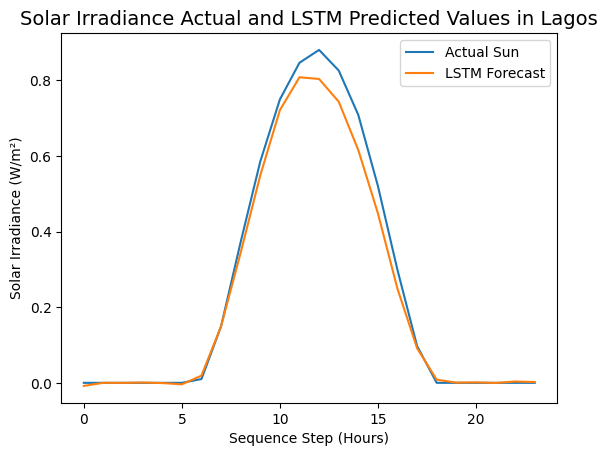

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.01002018 0.14953406 0.3725622  0.5855029  0.7497838  0.8468921
 0.88082427 0.8264963  0.70892495 0.5209434  0.29831877 0.09727159
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [-8.1703067e-03  7.7985227e-05 -4.2870641e-05  8.0271251e-04
 -5.6783110e-04 -3.9441381e-03  1.9038040e-02  1.4952837e-01
  3.4432238e-01  5.4887497e-01  7.2137368e-01  8.0853313e-01
  8.0392271e-01  7.4404800e-01  6.1598015e-01  4.4868731e-01
  2.4863765e-01  9.1645822e-02  8.3031543e-03  5.4328144e-04
  1.2796521e-03 -3.1669438e-04  3.5729110e-03  2.1474399e-03]


In [19]:
# To see your December 30th forecast:
plt.plot(lagos_actuals[0], label='Actual Sun')
plt.plot(lagos_lstm_preds[0], label='LSTM Forecast')
plt.title('Solar Irradiance Actual and LSTM Predicted Values in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", lagos_actuals[0])
print("LSTM predictions for the first test window:", lagos_lstm_preds[0])

In [20]:

df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Lagos Actual': lagos_actuals[0],
    'LSTM Predictions': lagos_lstm_preds[0]
})
display(df)

,Hour,Lagos Actual,LSTM Predictions
0,0,0.000000,-0.008170
1,1,0.000000,0.000078
2,2,0.000000,-0.000043
3,3,0.000000,0.000803
4,4,0.000000,-0.000568
5,5,0.000000,-0.003944
6,6,0.010020,0.019038
7,7,0.149534,0.149528
8,8,0.372562,0.344322
9,9,0.585503,0.548875


In [21]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)
r2, rmse = evaluate_model(lagos_actuals, lagos_lstm_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9870
RMSE: 0.0375


In [ ]:

# 2. Train GRU for Chester
gru_chester = solar_predictor_model(12, 64, model_type='GRU')
train_my_model(gru_chester, chester_loader, epochs=100)


Starting Training for GRU...
Epoch [10/100],  Loss: 0.006907
Epoch [20/100],  Loss: 0.003037
Epoch [30/100],  Loss: 0.001637
Epoch [40/100],  Loss: 0.001221
Epoch [50/100],  Loss: 0.000993
Epoch [60/100],  Loss: 0.000849
Epoch [70/100],  Loss: 0.000772
Epoch [80/100],  Loss: 0.000712
Epoch [90/100],  Loss: 0.000660
Epoch [100/100],  Loss: 0.000636
Training Complete!


In [23]:
print(len(chester_test))  # Check the column length to confirm
chester_ds_test = SolarDataset(chester_test, window=48, forecast=24)
# 3. Create the loader
chester_test_loader = DataLoader(chester_ds_test, batch_size=32, shuffle=False)

# Get predictions for GRU
chester_gru_preds, chester_actuals = test_model(gru_chester, chester_test_loader)

72


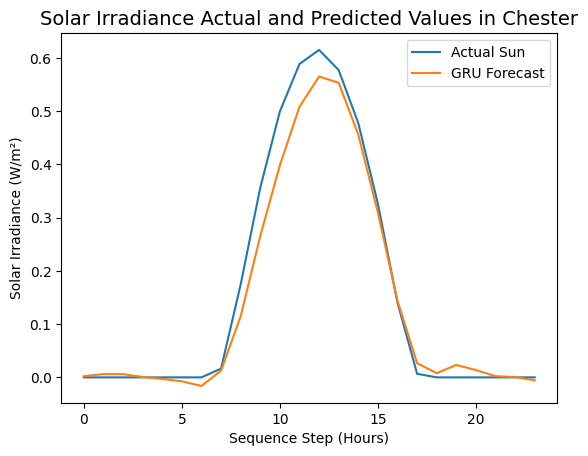

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.         0.0164819  0.17454363 0.35635382 0.49952993 0.5886478
 0.6150893  0.57716036 0.47756386 0.3261321  0.1401892  0.00678667
 0.         0.         0.         0.         0.         0.        ]
GRU predictions for the first test window: [ 0.00216955  0.00608856  0.00605216  0.00070792 -0.00300688 -0.00735311
 -0.01606609  0.01264523  0.11468998  0.26555246  0.39843848  0.50828165
  0.5651455   0.5533886   0.45602682  0.30958146  0.14370112  0.02656105
  0.00793226  0.0233092   0.0136873   0.00226499  0.00060445 -0.00554904]


In [24]:
# To see your December 30th forecast:
plt.plot(chester_actuals[0], label='Actual Sun')
plt.plot(chester_gru_preds[0], label='GRU Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", chester_actuals[0])
print("GRU predictions for the first test window:", chester_gru_preds[0])

In [25]:
df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Chester Actual': chester_actuals[0],
    'GRU Predictions': chester_gru_preds[0]
})
display(df)

,Hour,Chester Actual,GRU Predictions
0,0,0.000000,0.002170
1,1,0.000000,0.006089
2,2,0.000000,0.006052
3,3,0.000000,0.000708
4,4,0.000000,-0.003007
5,5,0.000000,-0.007353
6,6,0.000000,-0.016066
7,7,0.016482,0.012645
8,8,0.174544,0.114690
9,9,0.356354,0.265552


In [26]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)

r2, rmse = evaluate_model(chester_actuals, chester_gru_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9723
RMSE: 0.0376


In [ ]:

# Repeat for Lagos GRU
gru_lagos = solar_predictor_model(12, 64, model_type='GRU')
train_my_model(gru_lagos, lagos_loader, epochs=100)

Starting Training for GRU...
Epoch [10/100],  Loss: 0.003341
Epoch [20/100],  Loss: 0.002786
Epoch [30/100],  Loss: 0.001567
Epoch [40/100],  Loss: 0.000924
Epoch [50/100],  Loss: 0.000711
Epoch [60/100],  Loss: 0.000592
Epoch [70/100],  Loss: 0.000527
Epoch [80/100],  Loss: 0.000482
Epoch [90/100],  Loss: 0.000450
Epoch [100/100],  Loss: 0.000428
Training Complete!


In [28]:
from test import test_model

print(len(lagos_test))  # Check the column length to confirm
lagos_ds_test = SolarDataset(lagos_test, window=48, forecast=24)
# 3. Create the loader
lagos_test_loader = DataLoader(lagos_ds_test, batch_size=32, shuffle=False)

# Get predictions for GRU
lagos_gru_preds, lagos_actuals = test_model(gru_lagos, lagos_test_loader)

72


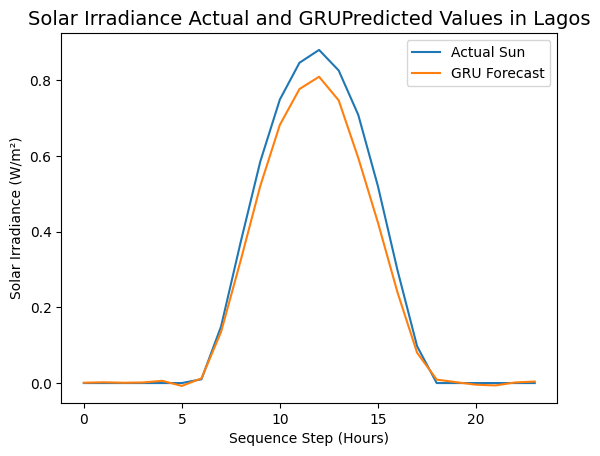

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.01002018 0.14953406 0.3725622  0.5855029  0.7497838  0.8468921
 0.88082427 0.8264963  0.70892495 0.5209434  0.29831877 0.09727159
 0.         0.         0.         0.         0.         0.        ]
GRU predictions for the first test window: [ 0.00084518  0.00210796  0.00084972  0.00157222  0.0059077  -0.00756677
  0.01234528  0.13528082  0.3239161   0.521011    0.68281066  0.77739435
  0.80990136  0.74743086  0.5951357   0.42460716  0.23965998  0.08016425
  0.00907771  0.00222254 -0.00432143 -0.00629944  0.00164285  0.00400786]


In [29]:
# To see your December 30th forecast:
plt.plot(lagos_actuals[0], label='Actual Sun')
plt.plot(lagos_gru_preds[0],  label='GRU Forecast')
plt.title('Solar Irradiance Actual and GRUPredicted Values in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", lagos_actuals[0])
print("GRU predictions for the first test window:", lagos_gru_preds[0])

In [30]:
df = pd.DataFrame({
    'Hour': list(range(0, 24)),
    'Lagos Actual': lagos_actuals[0],
    'GRU Predictions': lagos_lstm_preds[0]
})
display(df)

,Hour,Lagos Actual,GRU Predictions
0,0,0.000000,-0.008170
1,1,0.000000,0.000078
2,2,0.000000,-0.000043
3,3,0.000000,0.000803
4,4,0.000000,-0.000568
5,5,0.000000,-0.003944
6,6,0.010020,0.019038
7,7,0.149534,0.149528
8,8,0.372562,0.344322
9,9,0.585503,0.548875


In [ ]:
#evaluate model predictions with standard error metrics R squared and mean squared error (MSE)

from evaluate import evaluate_model

r2, rmse = evaluate_model(lagos_actuals, lagos_gru_preds)
print(f"R-Squared Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R-Squared Score: 0.9793
RMSE: 0.0472


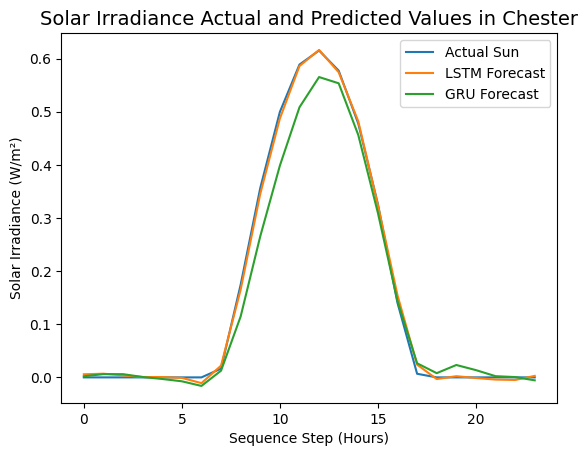

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.         0.0164819  0.17454363 0.35635382 0.49952993 0.5886478
 0.6150893  0.57716036 0.47756386 0.3261321  0.1401892  0.00678667
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [ 5.8403686e-03  6.9133956e-03  3.7976224e-03  7.4298866e-04
  5.7846261e-04 -8.9559238e-04 -1.0821945e-02  2.2129510e-02
  1.6518816e-01  3.4542453e-01  4.8710167e-01  5.8587170e-01
  6.1619598e-01  5.7419747e-01  4.8177338e-01  3.2433599e-01
  1.5446323e-01  2.3986433e-02 -3.1405026e-03  2.2167526e-03
 -1.1321791e-03 -4.1240379e-03 -4.8767850e-03  2.7946606e-03]
GRU predictions for the first test window: [ 0.00216955  0.00608856  0.00605216  0.00070792 -0.00300688 -0.00735311
 -0.01606609  0.01264523  0.11468998  0.26555246  0.39843848  0.50828165
  0.5651455   0.5533886   0.45602682  0.30958146  0.14370112  0.02656105
  0.00793226  0.0233092   

In [32]:
# To see both LSTM and GRU forecasts for the same test window:
plt.plot(chester_actuals[0], label='Actual Sun')
plt.plot(chester_lstm_preds[0], label='LSTM Forecast')
plt.plot(chester_gru_preds[0], label='GRU Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Chester', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", chester_actuals[0])
print("LSTM predictions for the first test window:", chester_lstm_preds[0])
print("GRU predictions for the first test window:", chester_gru_preds[0])

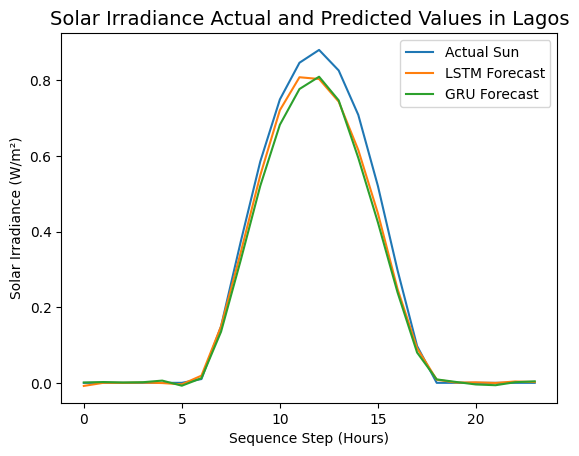

Actual values for the first test window: [0.         0.         0.         0.         0.         0.
 0.01002018 0.14953406 0.3725622  0.5855029  0.7497838  0.8468921
 0.88082427 0.8264963  0.70892495 0.5209434  0.29831877 0.09727159
 0.         0.         0.         0.         0.         0.        ]
LSTM predictions for the first test window: [-8.1703067e-03  7.7985227e-05 -4.2870641e-05  8.0271251e-04
 -5.6783110e-04 -3.9441381e-03  1.9038040e-02  1.4952837e-01
  3.4432238e-01  5.4887497e-01  7.2137368e-01  8.0853313e-01
  8.0392271e-01  7.4404800e-01  6.1598015e-01  4.4868731e-01
  2.4863765e-01  9.1645822e-02  8.3031543e-03  5.4328144e-04
  1.2796521e-03 -3.1669438e-04  3.5729110e-03  2.1474399e-03]
GRU predictions for the first test window: [ 0.00084518  0.00210796  0.00084972  0.00157222  0.0059077  -0.00756677
  0.01234528  0.13528082  0.3239161   0.521011    0.68281066  0.77739435
  0.80990136  0.74743086  0.5951357   0.42460716  0.23965998  0.08016425
  0.00907771  0.00222254 -

In [33]:
plt.plot(lagos_actuals[0], label='Actual Sun')
plt.plot(lagos_lstm_preds[0], label='LSTM Forecast')
plt.plot(lagos_gru_preds[0], label='GRU Forecast')
plt.title('Solar Irradiance Actual and Predicted Values in Lagos', fontsize=14)
plt.xlabel('Sequence Step (Hours)')
plt.ylabel('Solar Irradiance (W/m²)')
plt.legend()
plt.show()
print("Actual values for the first test window:", lagos_actuals[0])
print("LSTM predictions for the first test window:", lagos_lstm_preds[0])
print("GRU predictions for the first test window:", lagos_gru_preds[0])

In [34]:
# Check the device of the first parameter in your model
print(next(lstm_chester.parameters()).device)
print(next(lstm_lagos.parameters()).device)
print(next(gru_chester.parameters()).device)
print(next(gru_lagos.parameters()).device)

cpu
cpu
cpu
cpu


In [35]:
import numpy as np

chester_gru_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(chester_gru_preds)[1]), len(chester_gru_preds)),
    'prediction': np.asarray(chester_gru_preds).ravel()
})
chester_gru_df.to_csv('gru_chester_predictions.csv', index=False)

lagos_gru_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(lagos_gru_preds)[1]), len(lagos_gru_preds)),
    'prediction': np.asarray(lagos_gru_preds).ravel()
})
lagos_gru_df.to_csv('gru_lagos_predictions.csv', index=False)

chester_lstm_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(chester_lstm_preds)[1]), len(chester_lstm_preds)),
    'prediction': np.asarray(chester_lstm_preds).ravel()
})
chester_lstm_df.to_csv('lstm_chester_predictions.csv', index=False)

lagos_lstm_df = pd.DataFrame({
    'step': np.tile(np.arange(np.shape(lagos_lstm_preds)[1]), len(lagos_lstm_preds)),
    'prediction': np.asarray(lagos_lstm_preds).ravel()
})
lagos_lstm_df.to_csv('lstm_lagos_predictions.csv', index=False)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

raw_chester = pd.read_csv('./data_chester.csv')
raw_lagos = pd.read_csv('./data_lagos.csv')

# Chester (temperate) and Lagos (tropical) have very different solar
# irradiance ranges, so each location needs its own scaler.
chester_scaler = MinMaxScaler()
chester_scaler.fit(raw_chester[raw_chester.columns[7]].values.reshape(-1, 1))

lagos_scaler = MinMaxScaler()
lagos_scaler.fit(raw_lagos[raw_lagos.columns[7]].values.reshape(-1, 1))

# Descale predictions 
solarIrradiance_gruchester = chester_scaler.inverse_transform(chester_gru_preds)
solarIrradiance_lstmchester = chester_scaler.inverse_transform(chester_lstm_preds)
solarIrradiance_grulagos = lagos_scaler.inverse_transform(lagos_gru_preds)
solarIrradiance_lstmlagos = lagos_scaler.inverse_transform(lagos_lstm_preds)

# Descale the actuals too, so comparisons sit on the same real-world scale
chester_actuals_real = chester_scaler.inverse_transform(chester_actuals)
lagos_actuals_real = lagos_scaler.inverse_transform(lagos_actuals)

# Sanity check -- these should now look like plausible W/m^2 values
# (0 at night, peaking a few hundred at midday), not tiny 0-1 numbers.
print("Chester:")
display(pd.DataFrame({
    'Hour': range(24),
    'Actual': chester_actuals_real[0],
    'LSTM Prediction': solarIrradiance_lstmchester[0],
    'GRU Prediction': solarIrradiance_gruchester[0],
}))

print("Lagos:")
display(pd.DataFrame({
    'Hour': range(24),
    'Actual': lagos_actuals_real[0],
    'LSTM Prediction': solarIrradiance_lstmlagos[0],
    'GRU Prediction': solarIrradiance_grulagos[0],
}))

# Save descaled results to CSV for the dissertation write-up
pd.DataFrame({
    'step': np.tile(np.arange(solarIrradiance_gruchester.shape[1]), len(solarIrradiance_gruchester)),
    'actual': chester_actuals_real.ravel(),
    'gru_prediction': solarIrradiance_gruchester.ravel(),
    'lstm_prediction': solarIrradiance_lstmchester.ravel(),
}).to_csv('chester_descaled_predictions.csv', index=False)

pd.DataFrame({
    'step': np.tile(np.arange(solarIrradiance_grulagos.shape[1]), len(solarIrradiance_grulagos)),
    'actual': lagos_actuals_real.ravel(),
    'gru_prediction': solarIrradiance_grulagos.ravel(),
    'lstm_prediction': solarIrradiance_lstmlagos.ravel(),
}).to_csv('lagos_descaled_predictions.csv', index=False)



In [16]:
display(pd.read_csv('chester_descaled_predictions.csv'))
display(pd.read_csv('lagos_descaled_predictions.csv'))

,step,actual,gru_prediction,lstm_prediction
0,0,0.00000,2.215375,5.963717
1,1,0.00000,6.217153,7.059406
2,2,0.00000,6.179977,3.877828
3,3,0.00000,0.722871,0.758681
4,4,0.00000,-3.070382,0.590680
5,5,0.00000,-7.508404,-0.914507
6,6,0.00000,-16.405409,-11.050505
7,7,16.83000,12.912293,22.596886
8,8,178.23000,117.112236,168.676940
9,9,363.88000,271.160920,352.719900


,step,actual,gru_prediction,lstm_prediction
0,0,0.00000,0.879747,-8.504472
1,1,0.00000,2.194177,0.081175
2,2,0.00000,0.884470,-0.044624
3,3,0.00000,1.636524,0.835543
4,4,0.00000,6.149327,-0.591055
5,5,0.00000,-7.876256,-4.105454
6,6,10.43000,12.850201,19.816696
7,7,155.65001,140.813800,155.644070
8,8,387.80000,337.164280,358.405180
9,9,609.45000,542.320400,571.324000


In [20]:
#compute solar power output estimation (POE) for both cities using the descaled predictions
#using an illustrative example, we can assume a solar panel wattage of 500W and 50 panels for the calculation. The formula for calculating the power output is as follows:
# Power Output (W) = number of panels * rated panel wattage * (solar irradiance/1000) 
df = pd.read_csv('chester_descaled_predictions.csv')

chester_df = df.copy()
chester_power_output = pd.DataFrame({ 
     'Hour step': chester_df['step'].copy(),
     'Actual Solar Power Output (W)': (chester_df['actual']/1000) * 50 * 500 ,
     'LSTM Solar Power Output (W)': (chester_df['lstm_prediction']/1000) * 50 * 500,
     'GRU Solar Power Output (W)': (chester_df['gru_prediction']/1000) * 50 * 500
})

print("Chester:")
display(chester_power_output)

df = pd.read_csv('lagos_descaled_predictions.csv')

lagos_df = df.copy()
lagos_power_output = pd.DataFrame({ 
     'Hour step': lagos_df['step'].copy(),
     'Actual Solar Power Output (W)': (lagos_df['actual']/1000) * 50 * 500 ,
     'LSTM Solar Power Output (W)': (lagos_df['lstm_prediction']/1000) * 50 * 500,
     'GRU Solar Power Output (W)': (lagos_df['gru_prediction']/1000) * 50 * 500
})


print("Lagos:")
display(lagos_power_output)




Chester:


,Hour step,Actual Solar Power Output (W),LSTM Solar Power Output (W),GRU Solar Power Output (W)
0,0,0.000,149.092925,55.384380
1,1,0.000,176.485158,155.428815
2,2,0.000,96.945702,154.499413
3,3,0.000,18.967015,18.071785
4,4,0.000,14.766994,-76.759540
5,5,0.000,-22.862682,-187.710100
6,6,0.000,-276.262625,-410.135225
7,7,420.750,564.922150,322.807325
8,8,4455.750,4216.923500,2927.805900
9,9,9097.000,8817.997500,6779.023000


Lagos:


,Hour step,Actual Solar Power Output (W),LSTM Solar Power Output (W),GRU Solar Power Output (W)
0,0,0.00000,-212.611800,21.993670
1,1,0.00000,2.029370,54.854417
2,2,0.00000,-1.115601,22.111744
3,3,0.00000,20.888586,40.913088
4,4,0.00000,-14.776385,153.733182
5,5,0.00000,-102.636337,-196.906387
6,6,260.75000,495.417400,321.255025
7,7,3891.25025,3891.101750,3520.345000
8,8,9695.00000,8960.129500,8429.107000
9,9,15236.25000,14283.100000,13558.010000
